### Example 7.4: Oscillator warmup: Simple Harmonic Motion

(a) Generalize the single-variable methods that we have derived to the two-variable case relevant for oscillatory motion. 

(b) Integrate the equations of motion for single harmonic motion, i.e. with $F_k(x) = -kx$, for values of $k=4\pi^2$ and $m=1$ and *verify* that the numerical period $T$ agrees with the analytic result $T=2\pi \sqrt{m/k}$. You may choose the initial conditions (e.g. $p=0$ and $x=x_0$ at $t=t_0$, where $x_0$ would be the amplitude). 

(a) Let's implement the "vector" version of RK4.

$\vec{k}_1 = h \vec{f}(t_n, \vec{y}_n)$,

$\vec{k}_2 = h \vec{f}(t_n + \frac{1}{2} h, \vec{y}_n  + \frac{1}{2} \vec{k}_1)$,

$\vec{k}_3 = h \vec{f}(t_n + \frac{1}{2} h, \vec{y}_n + \frac{1}{2} \vec{k}_2)$,

$\vec{k}_4 = h \vec{f}(t_n + h, \vec{y}_n + \vec{k}_3)$,

$\vec{y}_{n+1} = \vec{y}_n + \frac{1}{6} (\vec{k}_1 + 2 \vec{k}_2 + 2 \vec{k}_3 + \vec{k}_4) + \mathcal{O}(h^5)$. 


In [7]:
import numpy as np

# test the zeros: 
testzeros = np.zeros((3,2))
print(testzeros)

# the function rk4 should take as input the vector f = (p/m, F_k(x))
# we need f, y0 = (x0, p0), the initial conditions, and we need to know the final time)
def rk4(f, y0, t0, tfinal, h): 
    """RK4 for one dimensional motion"""
    # calculate the number of steps N:
    N = int((tfinal - t0)/h)
    # set up the return arrays
    # the time array:
    ts = np.zeros(N)
    ys = np.zeros((N,2))
    # set the initial conditions
    ts[0] = t0
    ys[0] = y0
    # now apply rk4
    for n in range(1,N):
        yn = ys[n-1] # the previous step in terms of which we will obtain the next step
        tn = t0 + (n-1)*h
        k1 = h * f(tn,yn)
        k2 = h * f(tn+0.5*h, yn+0.5*k1)
        k3 = h * f(tn+0.5*h, yn+0.5*k2)
        k4 = h * f(tn+h, yn+k3)
        ys[n] = yn + (1/6)*(k1 + 2 * k2 + 2 * k3 + k4)
        # increment time
        ts[n] = tn + h
    return ts, ys

# implement the function for the RHS of the vector equation
def f_SHM(t, y):
    f1 = y[1] # this is p/m since y = (p/m, F_k(x))
    f2 = - 4 * np.pi**2 * y[0]# this should - k * x
    return np.array([f1, f2])
        

[[0. 0.]
 [0. 0.]
 [0. 0.]]


Let's integrate this with initial conditions $x(t=0) = 1$ and $p(t=0)=0$ from $t=0$ to $t=10$.

In [8]:
t0 = 0
t1 = 10

# the initial conditions:
y0 = [1,0]

# the time step
h = 1E-3

# let's solve
tsol, ysol = rk4(f_SHM, y0, t0, t1, h)

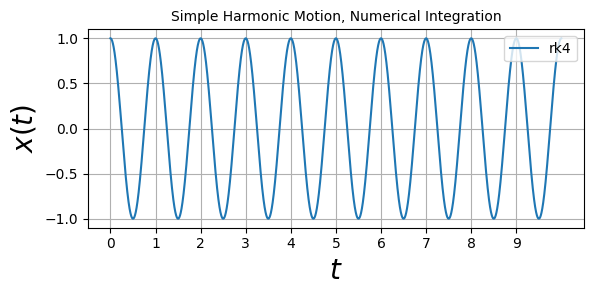

In [9]:
import matplotlib.pyplot as plt # import matplotlib, a conventional module name is plt
import numpy as np
from math import pi

fig, ax = plt.subplots() # create the elements required for matplotlib. This creates a figure containing a single axes.

# set the labels and titles:
ax.set_xlabel(r'$t$', fontsize=20) # set the x label
ax.set_ylabel(r'$x(t)$', fontsize=20) # set the y label. Note that the 'r' is necessary to remove the need for double slashes. You can use LaTeX! 
ax.set_title('Simple Harmonic Motion, Numerical Integration', fontsize=10) # set the title 

# make a one-dimensional plot using the above arrays, add a custom label
ax.plot(tsol, ysol.T[0], label='rk4') 

# set the ticks
ax.set_xticks(range(10))
ax.grid()
ax.set_aspect(2)

# construct the legend:
ax.legend(loc='upper right')  # Add a legend

plt.show() # show the plot here